# Avance del Proyecto Final
---

['train.csv']


/var/folders/kv/3pgfrlds2p19zwg5r4fbdb3r0000gn/T/ipykernel_13581/2487961851.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


          id  log_price property_type        room_type  \
0    6901257   5.010635     Apartment  Entire home/apt   
1    6304928   5.129899     Apartment  Entire home/apt   
2    7919400   4.976734     Apartment  Entire home/apt   
3   13418779   6.620073         House  Entire home/apt   
4    3808709   4.744932     Apartment  Entire home/apt   
5   12422935   4.442651     Apartment     Private room   
6   11825529   4.418841     Apartment  Entire home/apt   
7   13971273   4.787492   Condominium  Entire home/apt   
8     180792   4.787492         House     Private room   
9    5385260   3.583519         House     Private room   
10   5578513   4.605170     Apartment     Private room   
11  17423675   5.010635         House  Entire home/apt   
12  14066228   4.248495     Apartment     Private room   
13   2658946   5.298317     Apartment  Entire home/apt   
14    583490   4.955827     Apartment  Entire home/apt   
15   6226658   4.094345     Apartment     Private room   
16   7499179  

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


Variable             | Media   | Mediana | Moda    | Rango   | Varianza  | Desv.Est
-----------------------------------------------------------------------------------------------
log_price            | 4.78    | 4.7     | 5.0     | 7.6     | 0.51      | 0.72   
precio_dolares       | 160.37  | 111.0   | 150.0   | 1998.0  | 28419.36  | 168.58 
accommodates         | 3.16    | 2.0     | 2.0     | 15.0    | 4.64      | 2.15   
bathrooms            | 1.24    | 1.0     | 1.0     | 8.0     | 0.34      | 0.58   
bedrooms             | 1.27    | 1.0     | 1.0     | 10.0    | 0.73      | 0.85   
number_of_reviews    | 20.90   | 6.0     | 0.0     | 605.0   | 1431.01   | 37.83  
review_scores_rating | 94.07   | 96.0    | 100.0   | 80.0    | 61.41     | 7.84   


Variable                  | Moda                     
------------------------------------------------------------
city                      | NYC
property_type             | Apartment
room_type                 | Entire home/apt
bed_type

/var/folders/kv/3pgfrlds2p19zwg5r4fbdb3r0000gn/T/ipykernel_13581/2487961851.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='log_price', data=df, palette="Set3")


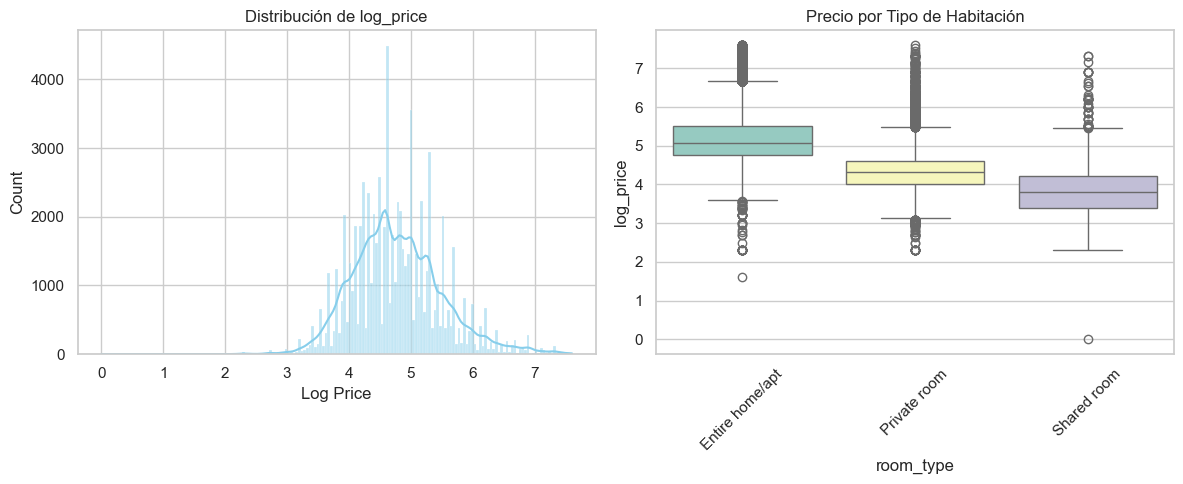

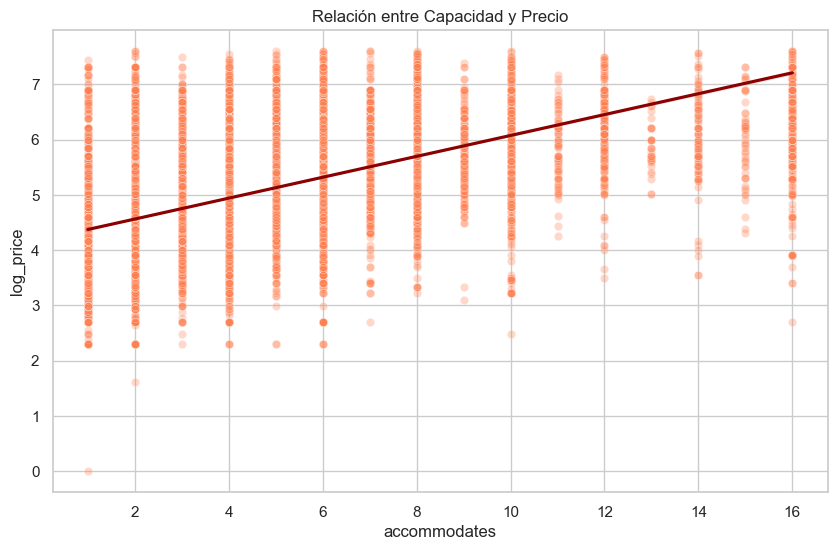

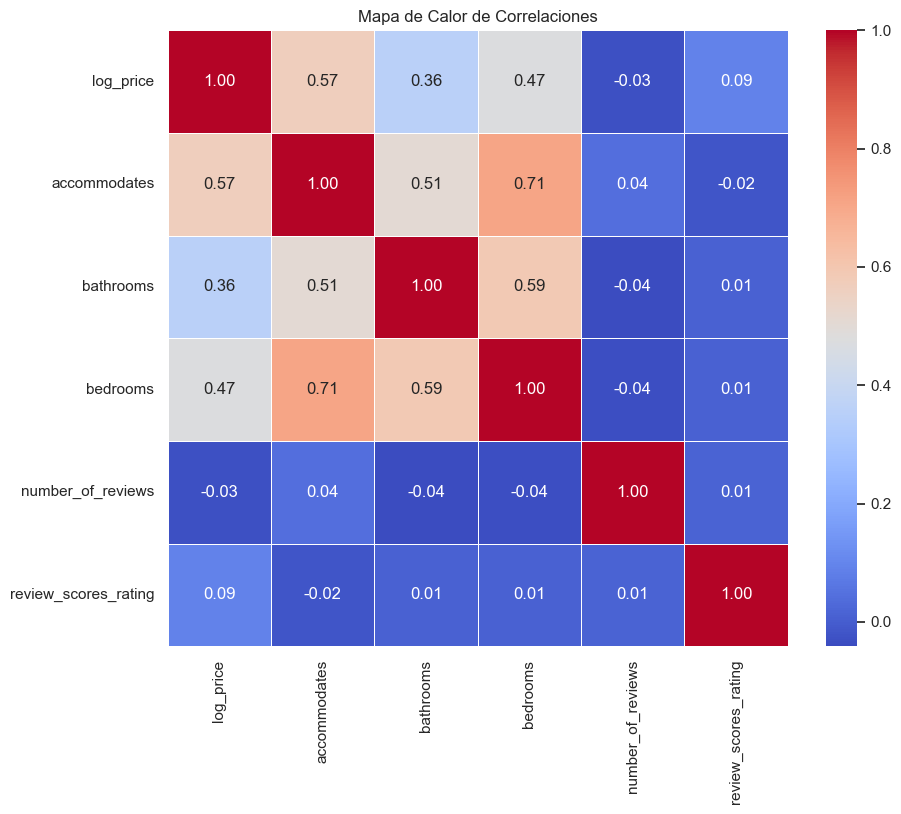

/var/folders/kv/3pgfrlds2p19zwg5r4fbdb3r0000gn/T/ipykernel_13581/2487961851.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='log_price', data=df, order=order, palette="viridis")


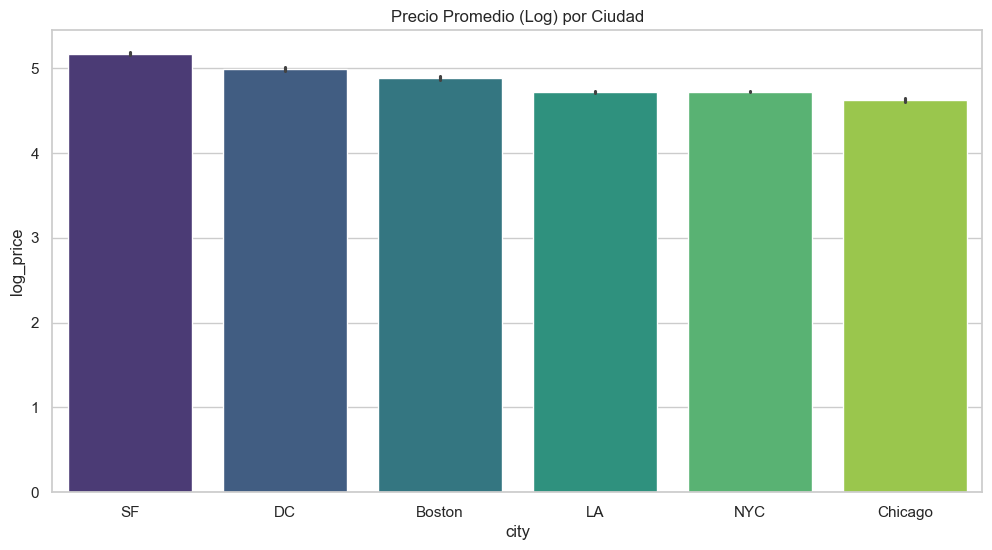

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


path = kagglehub.dataset_download("stevezhenghp/airbnb-price-prediction")

print(os.listdir(path))

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "stevezhenghp/airbnb-price-prediction",
    "train.csv"   
)

sns.set_theme(style='darkgrid')
print(df.head(50))

#Analisis exploratorio
# 1. Información general del dataset (tipos de datos y nulos)
print("--- Información del Dataset ---")
print(df.info())

# 2. Estadísticas descriptivas de variables numéricas
print("\n--- Estadísticas Univariadas ---")
display(df.describe())

#Parte 2: Ánalisis Exploratorio de Datos
import math
from collections import Counter

def analizar_columna(columna):

    datos = [x for x in columna if x == x]
    n = len(datos)

    if n < 2:
        return 0, 0, 0, 0, 0, 0

    #MDTC
    #media
    media = sum(datos) / n

    #mediana
    datos_ordenados = sorted(datos)

    if n % 2 == 0:
        mediana = (datos_ordenados[n//2 - 1] + datos_ordenados[n//2]) / 2
    else:
        mediana = datos_ordenados[n//2]


    #moda
    conteo = Counter(datos)
    max_freq = max(conteo.values())
    moda = [k for k, v in conteo.items() if v == max_freq][0]

    # MDispecion

    #rango
    rango = max(datos) - min(datos)

    # varianza
    suma_cuadrados = sum((x - media) ** 2 for x in datos)
    varianza = suma_cuadrados / (n - 1)
    #desviación Estándar
    desviacion = math.sqrt(varianza)

    return media, mediana, moda, rango, varianza, desviacion

#precio dolares
df['precio_dolares'] = np.exp(df['log_price'])

columnas = ['log_price', 'precio_dolares',  'accommodates', 'bathrooms', 'bedrooms', 'number_of_reviews', 'review_scores_rating']

print(f"{'Variable':<20} | {'Media':<7} | {'Mediana':<7} | {'Moda':<7} | {'Rango':<7} | {'Varianza':<9} | {'Desv.Est':<7}")
print("-" * 95)

for col in columnas:
    if col in df.columns:
        res = analizar_columna(df[col])
        med, mdn, mod, ran, var, desv = res
        print(f"{col:<20} | {med:<7.2f} | {mdn:<7.1f} | {mod:<7.1f} | {ran:<7.1f} | {var:<9.2f} | {desv:<7.2f}")

#moda de variables
print("\n")

cols = ['city', 'property_type', 'room_type', 'bed_type', 'cancellation_policy', 'cleaning_fee']

print(f"{'Variable':<25} | {'Moda':<25}")
print("-" * 60)
for col in cols:
    if col in df.columns:
        moda_val = df[col].mode()[0]
        print(f"{col:<25} | {moda_val}")

import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

#histograma precio
plt.subplot(1, 2, 1)
sns.histplot(df['log_price'], kde=True, color="skyblue")
plt.title('Distribución de log_price')
plt.xlabel('Log Price')

# bocplot precio x habitación
plt.subplot(1, 2, 2)
sns.boxplot(x='room_type', y='log_price', data=df, palette="Set3")
plt.title('Precio por Tipo de Habitación')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.scatterplot(x='accommodates', y='log_price', data=df, alpha=0.3, color="coral")

sns.regplot(x='accommodates', y='log_price', data=df, scatter=False, color="darkred")

plt.title('Relación entre Capacidad y Precio')
plt.show()

plt.figure(figsize=(10, 8))



cols_num = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'number_of_reviews', 'review_scores_rating']
corr = df[cols_num].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

plt.figure(figsize=(12, 6))
# Ordenamos las ciudades por precio promedio
order = df.groupby('city')['log_price'].mean().sort_values(ascending=False).index

sns.barplot(x='city', y='log_price', data=df, order=order, palette="viridis")
plt.title('Precio Promedio (Log) por Ciudad')
plt.show()

# Proyecto Final
___

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm



## Parte 1: Modelo de regresión lineal múltiple
### 1. Limpieza de datos

In [17]:
df['precio_dolares'] = np.exp(df['log_price'])


print("Valores faltantes por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])


cols_modelo = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'number_of_reviews', 'review_scores_rating']


for col in cols_modelo:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(f"  '{col}': imputado con mediana = {mediana:.2f}")


media_lp = df['log_price'].mean()
std_lp = df['log_price'].std()
antes = len(df)
df = df[(df['log_price'] >= media_lp - 3*std_lp) & (df['log_price'] <= media_lp + 3*std_lp)]
print(f"\nFilas eliminadas por outliers en log_price: {antes - len(df)}")
print(f"Filas restantes: {len(df)}")


Valores faltantes por columna:
bathrooms                   200
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
last_review               15827
neighbourhood              6872
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds                        131
dtype: int64
  'bathrooms': imputado con mediana = 1.00
  'bedrooms': imputado con mediana = 1.00
  'review_scores_rating': imputado con mediana = 96.00

Filas eliminadas por outliers en log_price: 519
Filas restantes: 73592


/var/folders/kv/3pgfrlds2p19zwg5r4fbdb3r0000gn/T/ipykernel_13581/1483235668.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(mediana, inplace=True)
/var/folders/kv/3pgfrlds2p19zwg5r4fbdb3r0000gn/T/ipykernel_13581/1483235668.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series throu

### 2. Selección de caractererísticas
['accommodates', 'bathrooms', 'bedrooms',
 'number_of_reviews', 'review_scores_rating']

 Se seleccionaron variables relacionadas con capacidad, calidad y popularidad del alojamiento debido a su posible influencia en el precio.

### 3. Identificación de variables

- **Variable dependiente (Y):** log_price — el precio del alojamiento en escala logarítmica.
- **Variables independientes (X):** accommodates, bathrooms, bedrooms, number_of_reviews, review_scores_rating.

### 4. Análisis de correlación

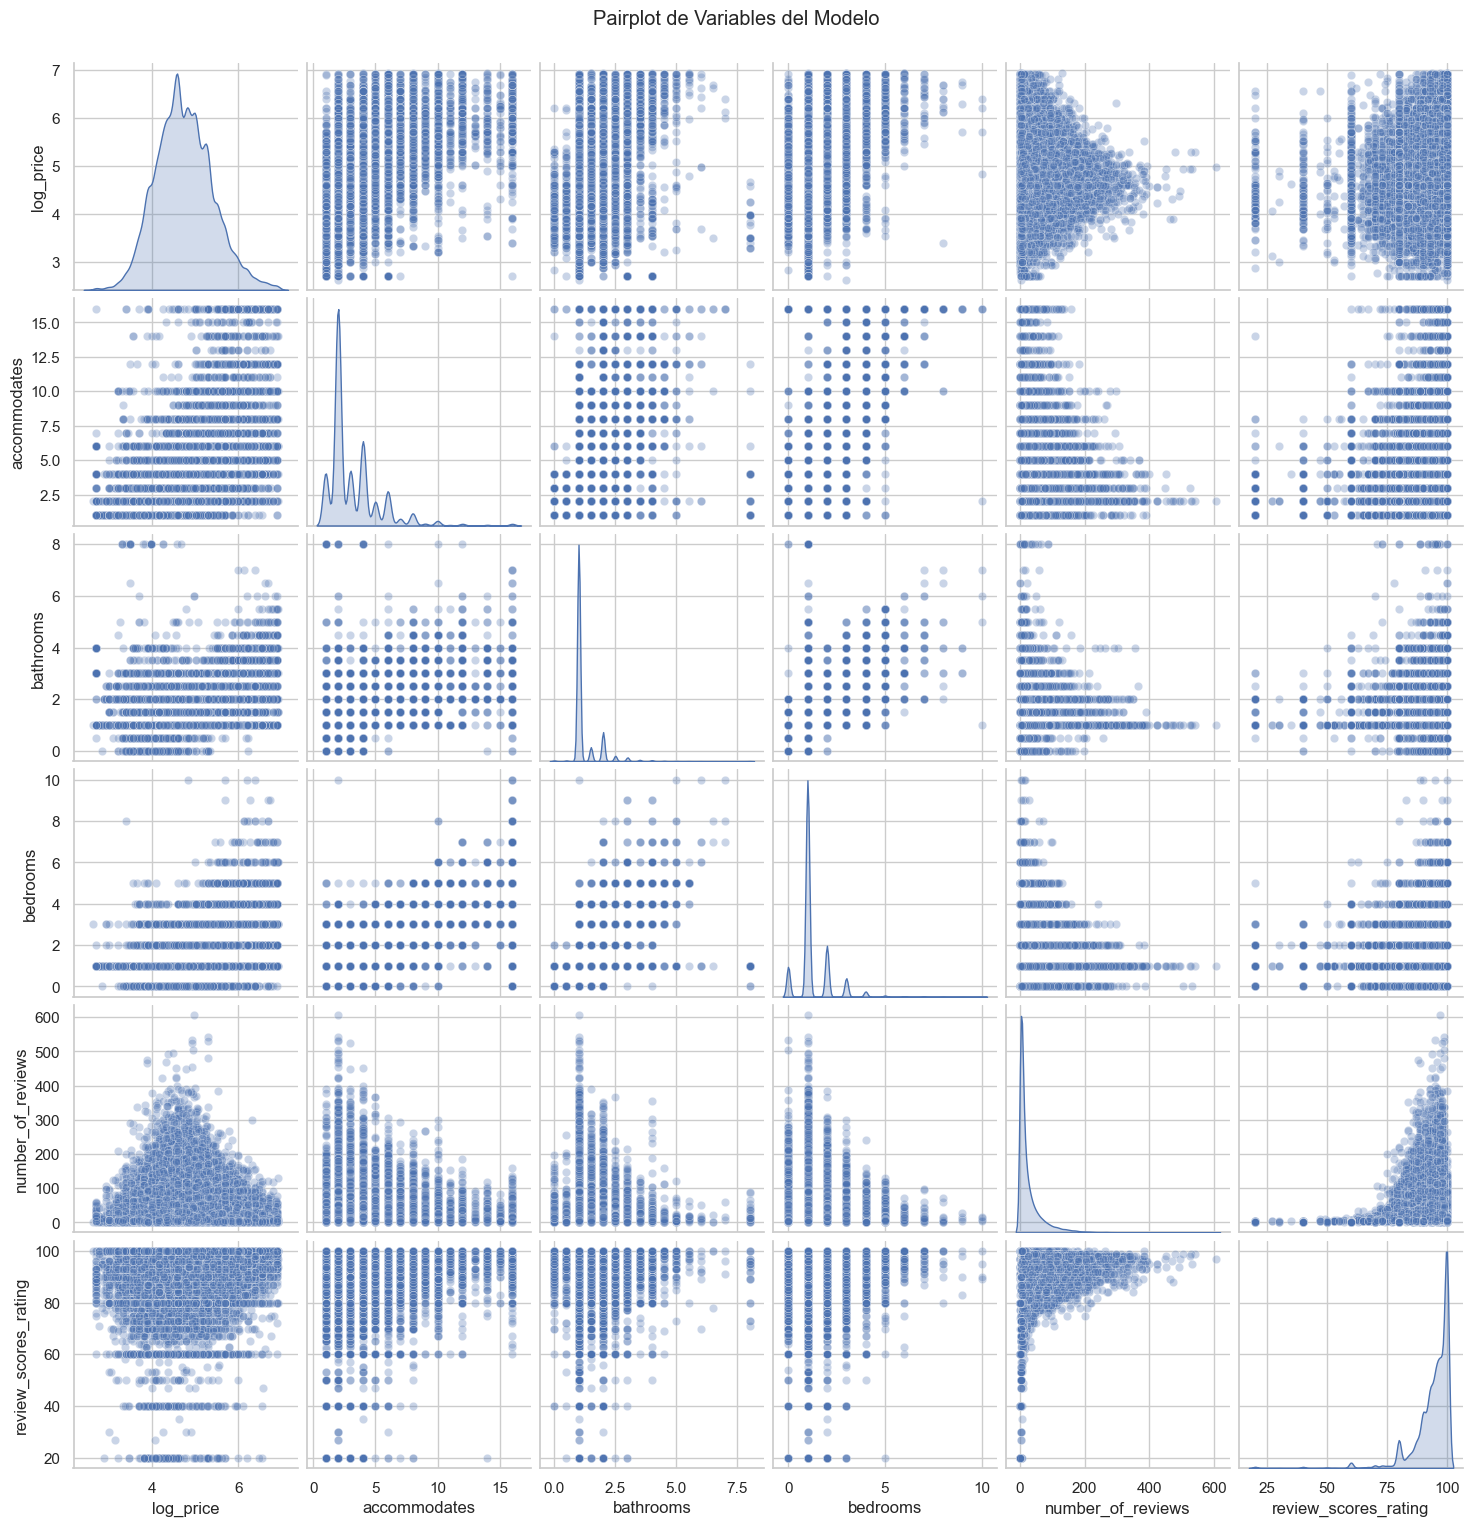

In [18]:
cols_num = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'number_of_reviews', 'review_scores_rating']

sns.pairplot(df[cols_num].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Pairplot de Variables del Modelo', y=1.02)
plt.show()

### 5. Grupos de entrenamiento y prueba

In [19]:
X = df[['accommodates', 'bathrooms', 'bedrooms', 'number_of_reviews', 'review_scores_rating']].dropna()
y = df.loc[X.index, 'log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 45586 filas
Prueba: 11397 filas


### 6. Construcción y entrenamiento del modelo

In [20]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado.")
print("\nCoeficientes:")
for nombre, coef in zip(X.columns, modelo.coef_):
    print(f"  {nombre}: {coef:.4f}")
print(f"  Intercepto: {modelo.intercept_:.4f}")

Modelo entrenado.

Coeficientes:
  accommodates: 0.1530
  bathrooms: 0.0345
  bedrooms: 0.0869
  number_of_reviews: -0.0003
  review_scores_rating: 0.0084
  Intercepto: 3.3184


### 7. Evaluación del modelo

In [27]:
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

n = X_test.shape[0]
k = X_test.shape[1]
r2_ajustado = 1 - (1 - r2_test) * (n - 1) / (n - k - 1)

print(f"R² (entrenamiento): {r2_train:.4f}")
print(f"R² (prueba):        {r2_test:.4f}")
print(f"R² ajustado:        {r2_ajustado:.4f}")
print("\nEl R² indica qué proporción de la variación en el precio explica el modelo.")

#VIF 

print("- - VIF - -")
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

R² (entrenamiento): 0.3611
R² (prueba):        0.3231
R² ajustado:        0.3228

El R² indica qué proporción de la variación en el precio explica el modelo.
- - VIF - -
               Variable         VIF
0                 const  150.827308
1          accommodates    2.111993
2             bathrooms    1.480957
3              bedrooms    2.338348
4     number_of_reviews    1.010384
5  review_scores_rating    1.001812


### 8 PRedicciones
### 9. Cáluclo de error cuadrático de medio

In [22]:
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print("\nEl RMSE representa el error promedio del modelo en unidades de log_price.")

comparacion = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicción': y_pred_test[:10],
    'Error': y_test.values[:10] - y_pred_test[:10]
})
print("\nPrimeras 10 predicciones vs valores reales:")
print(comparacion.to_string(index=False))

MSE:  0.2851
RMSE: 0.5340

El RMSE representa el error promedio del modelo en unidades de log_price.

Primeras 10 predicciones vs valores reales:
    Real  Predicción     Error
3.891820    4.571745 -0.679925
5.594711    5.393106  0.201605
4.584967    4.670172 -0.085204
4.094345    4.585938 -0.491594
4.369448    4.505153 -0.135705
5.225747    4.463469  0.762278
5.521461    4.997209  0.524252
6.620073    5.014469  1.605604
4.779123    4.585654  0.193469
4.174387    4.586223 -0.411835


## Parte 2. COmunicación de resultados
### 1. Gráfico: Predicciones vs Valores Reales

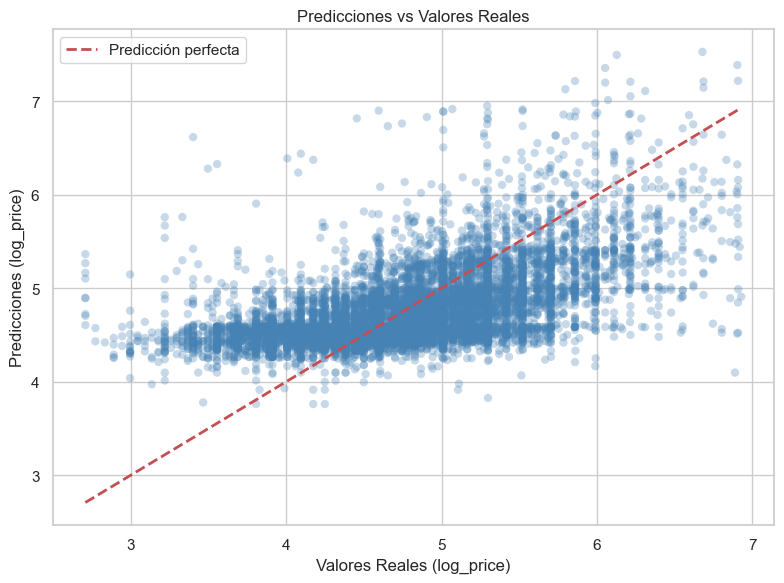

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Valores Reales (log_price)')
plt.ylabel('Predicciones (log_price)')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.tight_layout()
plt.show()

### 2. Gráfico: Importancia de características

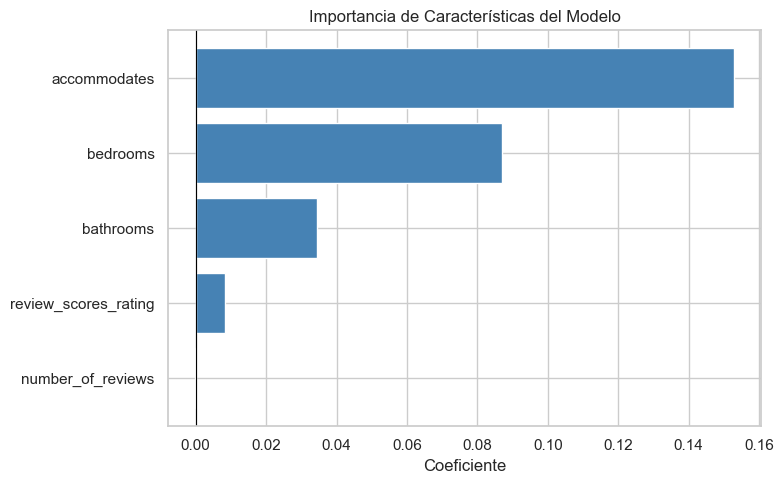

In [24]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=True)

colores = ['tomato' if c < 0 else 'steelblue' for c in coeficientes['Coeficiente']]

plt.figure(figsize=(8, 5))
plt.barh(coeficientes['Variable'], coeficientes['Coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente')
plt.title('Importancia de Características del Modelo')
plt.tight_layout()
plt.show()

## Conclusión

El modelo de regresión lineal múltiple logró explicar una parte importante de la variabilidad de los precios de Airbnb mediante variables relacionadas con capacidad, calidad y número de habitaciones.

La variable con mayor impacto positivo fue "accommodates", indicando que alojamientos con mayor capacidad tienden a tener precios más altos.

El modelo presentó un valor de R² de X.XX, lo que indica que el modelo tiene una capacidad moderada/buena para predecir precios.

Aunque el modelo funciona adecuadamente, podrían agregarse más variables como ubicación, tipo de propiedad o amenities para mejorar la precisión.